In [1]:
from sklearn import svm

In [12]:
# features
X = [
  [-3, -1],
  [0, -2],
  [-2.5, 2],
  [-1, -1],
  [3, 0.5],
  [.5, 3],
  [-3, -3],
]

In [13]:
# labeles
y = [0,1,0,1,1,0,1]

In [14]:
clf = svm.SVC(kernel="linear").fit(X, y)

In [16]:
clf.predict([[2,4]])

array([0])

In [27]:
clf.predict([[-1,2]])

array([0])

In [ ]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

In [21]:
import numpy as np

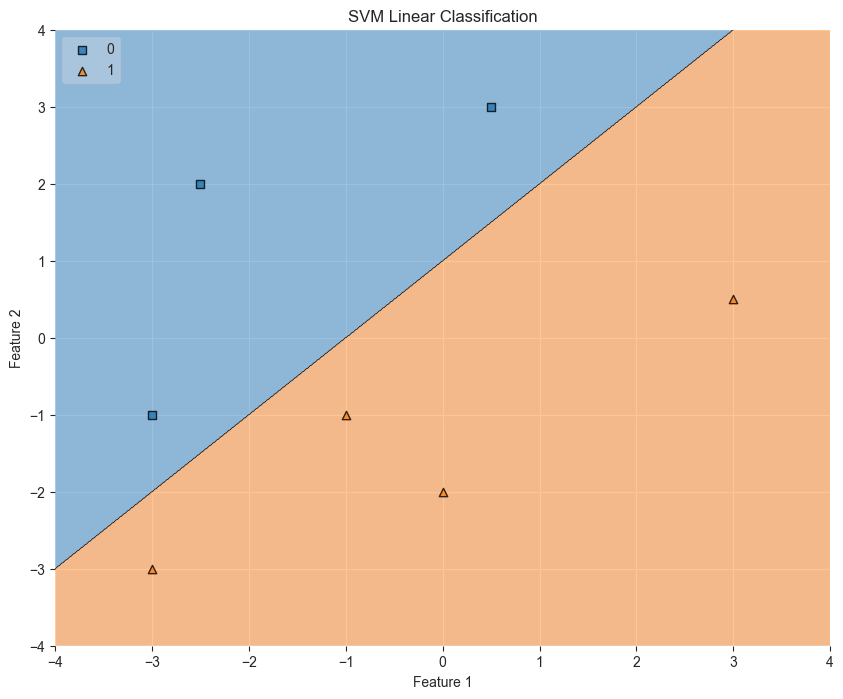

In [22]:
plt.figure(figsize=(10, 8))
plot_decision_regions(np.array(X), np.array(y), clf=clf, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Linear Classification')
plt.show()

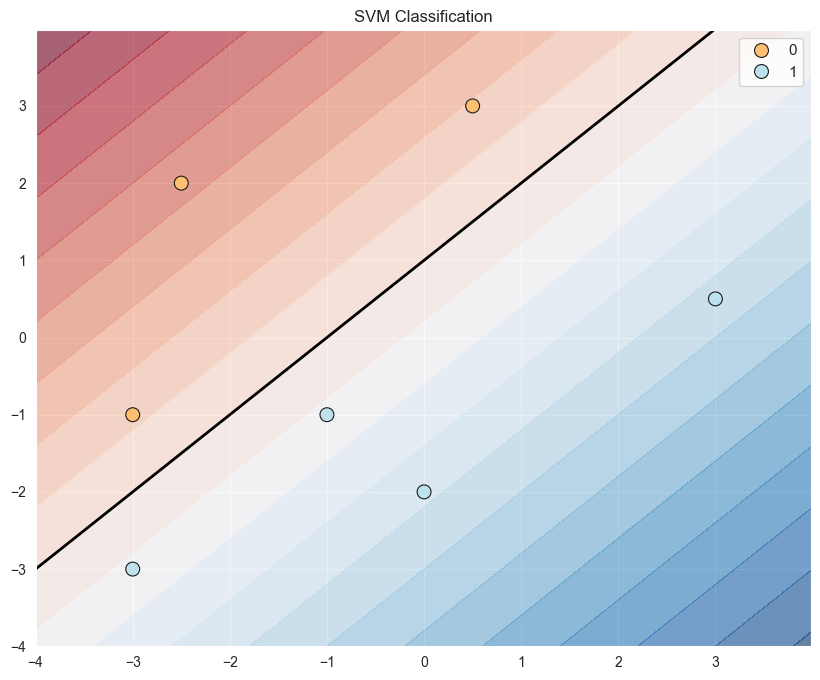

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Create mesh
h = 0.02
x_min, x_max = np.array(X)[:, 0].min() - 1, np.array(X)[:, 0].max() + 1
y_min, y_max = np.array(X)[:, 1].min() - 1, np.array(X)[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot with seaborn style
sns.set_theme(style="whitegrid")
ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')

# Scatter with seaborn
sns.scatterplot(x=np.array(X)[:, 0], y=np.array(X)[:, 1], hue=y,
 palette='RdYlBu', s=100, edgecolor='k', ax=ax)
ax.set_title('SVM Classification')
plt.show()

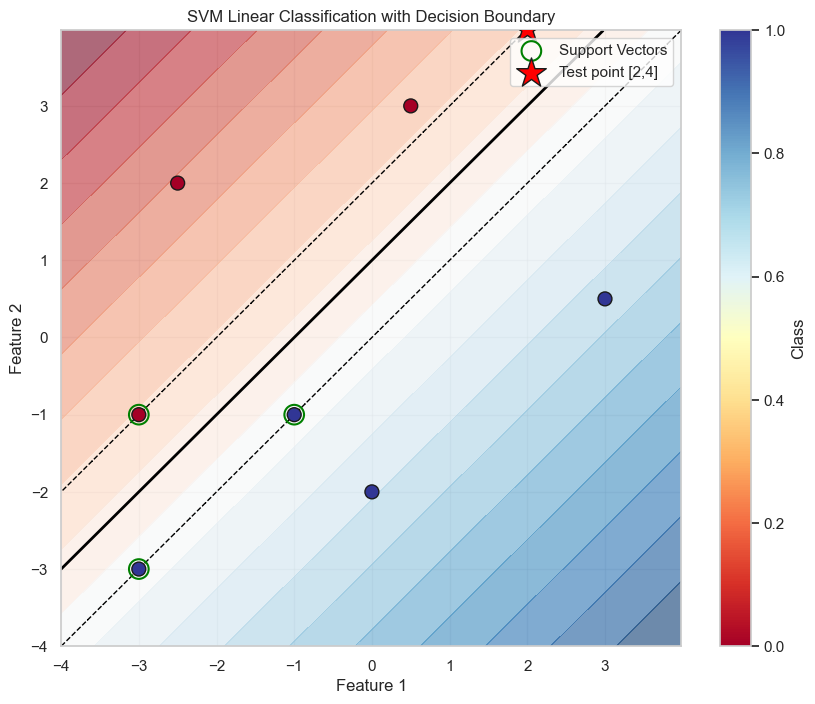

In [26]:
# Create a mesh to plot decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = min([p[0] for p in X]) - 1, max([p[0] for p in X]) + 1
y_min, y_max = min([p[1] for p in X]) - 1, max([p[1] for p in X]) + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
np.arange(y_min, y_max, h))

# Predict on mesh
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary and margins
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap=plt.cm.RdBu, alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')  # Decision boundary
plt.contour(xx, yy, Z, levels=[-1, 1], linewidths=1, colors='black', linestyles='dashed')  # Margins

# Plot training points
scatter = plt.scatter(np.array(X)[:, 0], np.array(X)[:, 1], c=y, cmap=plt.cm.RdYlBu,
edgecolors='k', s=100, zorder=3)

# Highlight support vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
s=200, linewidth=1.5, facecolors='none', edgecolors='green',
label='Support Vectors', zorder=4)

# Plot the test point
plt.scatter([2], [4], marker='*', s=500, c='red', edgecolors='k', label='Test point [2,4]', zorder=5)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Linear Classification with Decision Boundary')
plt.legend()
plt.colorbar(scatter, label='Class')
plt.grid(True, alpha=0.3)
plt.show()